### RE ROUTE

In [19]:
import sys
import pathlib

# Get project root (parent of generation/)
project_root = pathlib.Path().resolve().parent
sys.path.insert(0, str(project_root))

### MANIFESTO

In [20]:
from scripts.utils.logger import logger

In [21]:
logger_params = {
    "main_folder": "/home/think/Desktop/MOCK",
    "experiment_name": "Consolidation",
    "date": "2025-09-07",
    "iteration": 69,
    "description": (
        "Se va a consolidar la funcion generadora "
        " de sistemas caoticos, esta sera modular."
        "Es decir, vamos a hacerlo solo para Lorenz con la posibilidad de solo tener"
        "que cambiar la defincion al principio"
        "con dos modos de generacion"
        "- Mismos params, diferentes i.c."
        "- Diferentes params, mismas i.c"
    )
}

In [22]:
exp_folder, manifesto_path = logger(logger_params)
print(f"Experiment folder created at: {exp_folder}")
print(f"Manifesto written to: {manifesto_path}")

Experiment folder created at: /home/think/Desktop/MOCK/Consolidation_2025-09-07_iter69
Manifesto written to: /home/think/Desktop/MOCK/Consolidation_2025-09-07_iter69/manifesto.txt


### LORENZ63

In [ ]:
from scripts.data_generation.binder import Binder
from scripts.utils.plastic_surgeon import from_sol_to_df
import numpy as np
from scipy.integrate import solve_ivp
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from scripts.data_generation.tsdg import DynamicalSystem

Approximate largest Lyapunov exponent: 0.8420229000138758


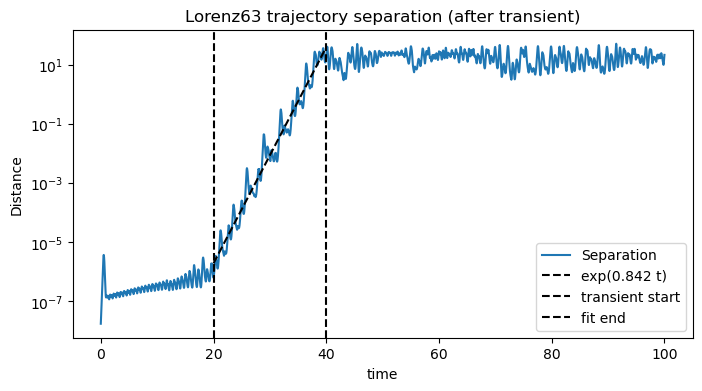

In [ ]:
model_name = 'lorenz63'

sigma = 10 
beta = 8/3
rho = 28
params = (sigma, beta, rho)


binder = Binder("scripts.systems.lorenz63", "lorenz63", params)
binder.import_module()      # will reload if module is already in memory
model_fixed = binder.fixer()


t_span = (0, 100)
t_eval = np.linspace(t_span[0], t_span[1], 10000)
y0 = np.array([0.1, 0.1, 0.1])

ds1 = DynamicalSystem(model_fixed, y0, t_eval, notebook = True)
_ = ds1.solve()
eps = 1e-8
y0_perturbed = y0 + eps
ds2 = DynamicalSystem(model_fixed, y0_perturbed, t_eval, notebook=True)
_ = ds2.solve()



# Compute full 3D separation
delta = np.linalg.norm(ds1.solution.y - ds2.solution.y, axis=0)
delta0 = delta[0]  # should be close to eps

t = ds1.solution.t

# Define transient cutoff and linear fitting window
transient = 20   # skip first 15 time units
fit_end = 40     # fit up to t=45

# Select the fitting region after transient
linear_idx = (t > transient) & (t < fit_end)
t_linear = t[linear_idx]
delta_linear = delta[linear_idx]

# Fit a line to log(delta) to get slope = Lyapunov exponent
slope, intercept = np.polyfit(t_linear, np.log(delta_linear), 1)
lambda_max = slope
print("Approximate largest Lyapunov exponent:", lambda_max)

# Plot
plt.figure(figsize=(8,4))
plt.semilogy(t, delta, label='Separation')
plt.semilogy(t_linear, np.exp(intercept + slope*t_linear), 'k--', 
             label=f'exp({lambda_max:.3f} t)')

# Add vertical lines for transient and fit end
plt.axvline(transient, color='k', linestyle='--', label='transient start')
plt.axvline(fit_end, color='k', linestyle='--', label='fit end')

plt.xlabel('time')
plt.ylabel('Distance')
plt.title('Lorenz63 trajectory separation (after transient)')
plt.legend()
plt.show()


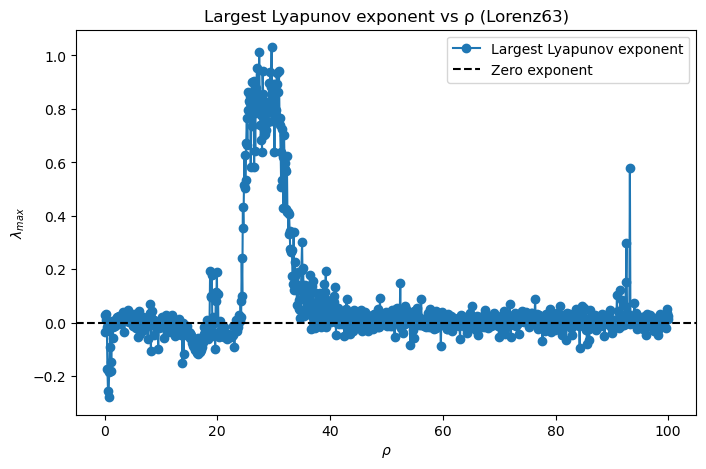

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Original parameters
sigma = 10
beta = 8/3
rho_values = np.linspace(0, 100, 1000)  
params_base = (sigma, beta, None)    # placeholder for rho

# Store Lyapunov exponents
lambda_max_list = []

# Loop over rho
for rho in rho_values:
    # Update model with new rho
    params = (sigma, beta, rho)
    binder = Binder("scripts.systems.lorenz63", "lorenz63", params)
    binder.import_module()
    model_fixed_rho = binder.fixer()
    
    # Solve trajectories (keep y0 same)
    ds1_rho = DynamicalSystem(model_fixed_rho, y0, t_eval, notebook=True)
    _ = ds1_rho.solve()
    
    y0_perturbed = y0 + eps
    ds2_rho = DynamicalSystem(model_fixed_rho, y0_perturbed, t_eval, notebook=True)
    _ = ds2_rho.solve()
    
    # Compute separation
    delta = np.linalg.norm(ds1_rho.solution.y - ds2_rho.solution.y, axis=0)
    t = ds1_rho.solution.t
    
    # Linear fit window (after transient)
    linear_idx = (t > transient) & (t < fit_end)
    t_linear = t[linear_idx]
    delta_linear = delta[linear_idx]
    
    # Linear fit of log(delta) to get Lyapunov exponent
    slope, intercept = np.polyfit(t_linear, np.log(delta_linear), 1)
    lambda_max_list.append(slope)

# Plot Lyapunov exponent vs rho
plt.figure(figsize=(8,5))
plt.plot(rho_values, lambda_max_list, 'o-', label='Largest Lyapunov exponent')
plt.axhline(0, color='k', linestyle='--', label='Zero exponent')
plt.xlabel(r'$\rho$')
plt.ylabel(r'$\lambda_{max}$')
plt.title('Largest Lyapunov exponent vs ρ (Lorenz63)')
plt.legend()
plt.show()


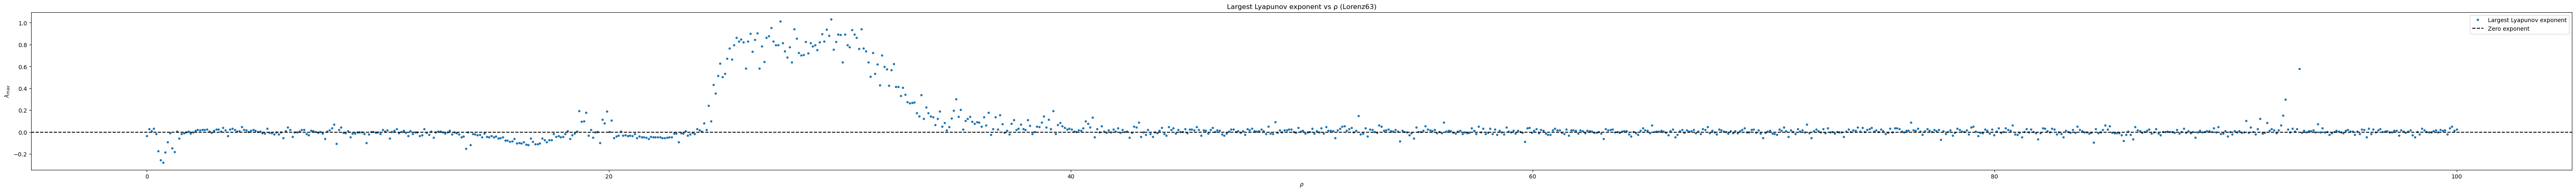

In [370]:
# Plot Lyapunov exponent vs rho
plt.figure(figsize=(80,5))
plt.plot(rho_values, lambda_max_list, '.', label='Largest Lyapunov exponent')
plt.axhline(0, color='k', linestyle='--', label='Zero exponent')
plt.xlabel(r'$\rho$')
plt.ylabel(r'$\lambda_{max}$')
plt.title('Largest Lyapunov exponent vs ρ (Lorenz63)')
plt.legend()
plt.show()


### 3 Dimensions

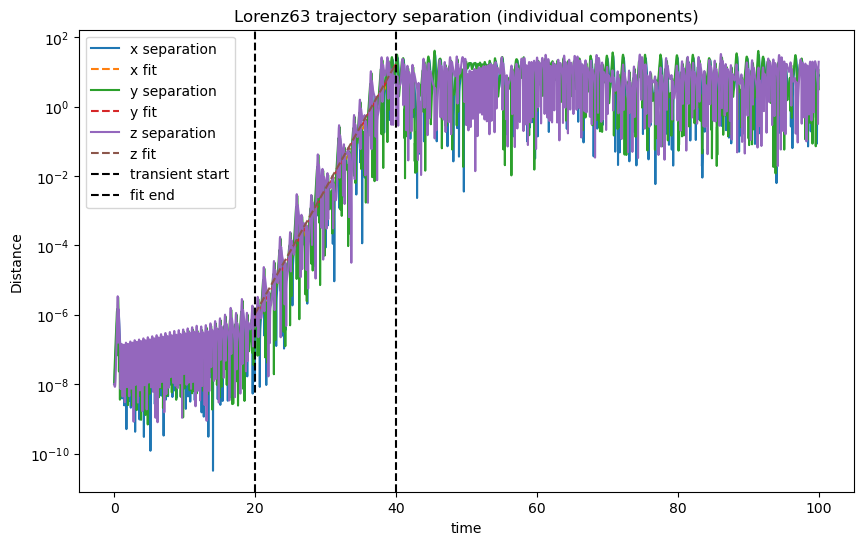

Approximate largest Lyapunov exponent per component: [0.8490722671602107, 0.8451538438452858, 0.8305441984502174]


In [351]:
import numpy as np
import matplotlib.pyplot as plt

# Assume ds1 and ds2 are already solved as in your code

t = ds1.solution.t
y1 = ds1.solution.y  # shape (3, N)
y2 = ds2.solution.y

eps = 1e-8

# Transient and fitting window
transient = 20
fit_end = 40
linear_idx = (t > transient) & (t < fit_end)
t_linear = t[linear_idx]

lambda_components = []
plt.figure(figsize=(10,6))

for i, coord in enumerate(['x','y','z']):
    delta_i = np.abs(y1[i] - y2[i])
    
    delta_linear = delta_i[linear_idx]
    
    # Fit log(delta) to line to estimate Lyapunov exponent
    slope, intercept = np.polyfit(t_linear, np.log(delta_linear), 1)
    lambda_components.append(slope)
    
    # Plot each component
    plt.semilogy(t, delta_i, label=f'{coord} separation')
    plt.semilogy(t_linear, np.exp(intercept + slope*t_linear), '--', label=f'{coord} fit')

plt.axvline(transient, color='k', linestyle='--', label='transient start')
plt.axvline(fit_end, color='k', linestyle='--', label='fit end')

plt.xlabel('time')
plt.ylabel('Distance')
plt.title('Lorenz63 trajectory separation (individual components)')
plt.legend()
plt.show()

print("Approximate largest Lyapunov exponent per component:", lambda_components)


In [350]:
import nolds
df = ds1.to_dataframe()  # does not save by default
# # Feature Extraction
# lyap = nolds.lyap_r(df['x'])
# import nolds
lyap = nolds.lyap_r(df['x'], emb_dim=3, min_tsep=1)

print("Lyapunov Exponent:", lyap)

Lyapunov Exponent: 0.023043387242090315
